# Experiment No. 8 — Customer Churn Prediction using Decision Tree Classification

| | |
|---|---|
| **Name** | Abhigyan Dubey |
| **Course & Branch** | B.Tech CSE |
| **CUID** | CU24250059 |
| **Subject** | Mastery in Data Analytics and Visualizations and Career Advancement |
| **Sem & Section** | 5th Sem, Section "B" |

---
## Aim
To build and evaluate a Decision Tree Classification model for predicting customer churn using a real-world dataset (Telco Customer Churn) and analyze the factors influencing customer retention.

## Purpose
Customer churn prediction is a supervised machine-learning application that identifies customers likely to discontinue a service. Early identification lets a business apply targeted retention strategies, improve customer satisfaction and reduce revenue loss.

## Prerequisites
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, and basic knowledge of supervised learning, classification, preprocessing and feature encoding. Runs on Jupyter Notebook or Google Colab.

## Step 1 & 2 — Select the dataset, import libraries and load the data
**Dataset chosen:** *Telco Customer Churn Dataset* (IBM sample data) — 7,043 customers of a telecom company, 21 columns.
The target column is **`Churn`** (Yes = customer left within the last month, No = customer stayed). The other columns describe demographics (gender, senior citizen, partner, dependents), account information (tenure, contract, payment method, billing) and subscribed services (phone, internet, security, streaming, etc.).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Load from a local file if present (e.g. uploaded to Colab), otherwise download a public copy.
FILE = "Telco-Customer-Churn.csv"
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(FILE if os.path.exists(FILE) else URL)

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Step 3 — Data preprocessing
1. **Handle missing values** — `TotalCharges` is read as text because 11 rows contain a blank space. We convert it to numeric and inspect those rows.
2. **Identifier and duplicates** — `customerID` is unique for every customer and has no predictive value, so it is dropped. We also check for duplicate records.
3. **Encode the target** — `Churn`: Yes → 1, No → 0.
4. **Encode categorical variables** — one-hot encoding (`pd.get_dummies`). Decision Trees do **not** need feature scaling, so no scaler is used.

In [3]:
# 1. Missing values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")
print("Missing values after conversion:\n", df.isnull().sum()[df.isnull().sum() > 0], "\n")
print("Rows with missing TotalCharges (note their tenure):")
display(df.loc[df["TotalCharges"].isnull(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head())

Missing values after conversion:
 TotalCharges    11
dtype: int64 

Rows with missing TotalCharges (note their tenure):


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No


All 11 rows with a missing `TotalCharges` have **tenure = 0**, i.e. they are brand-new customers who have not been billed yet. So the correct value is **0**, and we fill it with 0 instead of dropping the rows.

In [4]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 2. Duplicates and identifier
print("Duplicate rows (ignoring customerID):", df.drop(columns="customerID").duplicated().sum())
df = df.drop(columns="customerID")

# 3. Target encoding
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# 4. One-hot encoding of categorical features
y = df["Churn"]
X = pd.get_dummies(df.drop(columns="Churn"), drop_first=True)

print("\nFeature matrix shape after encoding:", X.shape)
print("Missing values left:", int(X.isnull().sum().sum()))
X.head()

Duplicate rows (ignoring customerID): 22

Feature matrix shape after encoding: (7043, 30)
Missing values left: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


**Note on duplicates:** 22 rows have identical feature values once `customerID` is removed. They belong to *different* customers (mostly new customers on similar plans), so they are genuine records and are **kept**.

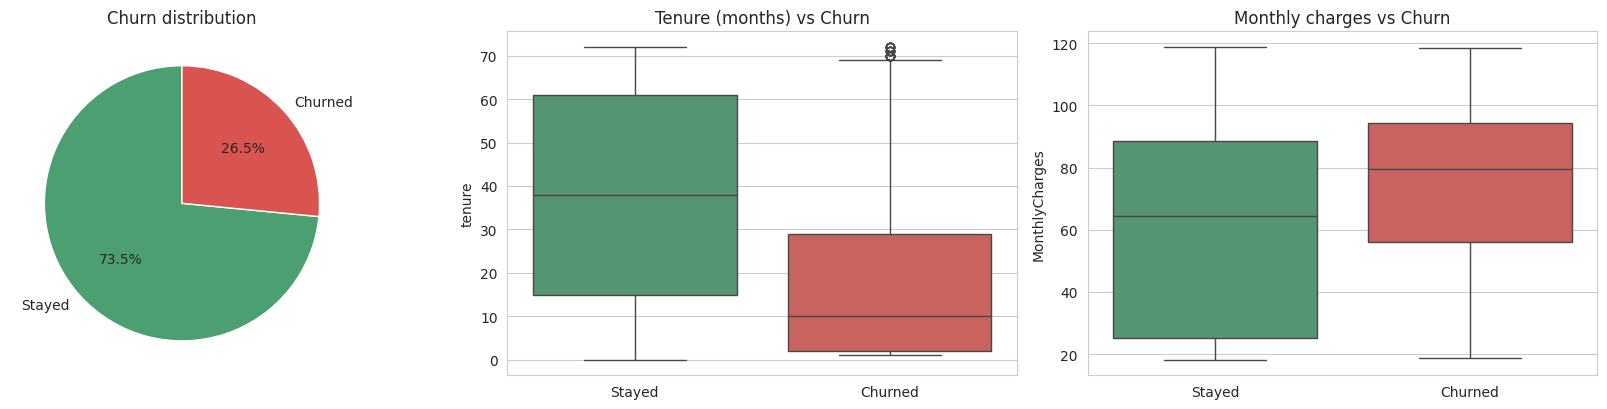

In [5]:
# Class balance and quick look at the data
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

churn_pct = y.value_counts(normalize=True).rename({0: "Stayed", 1: "Churned"}) * 100
axes[0].pie(churn_pct, labels=churn_pct.index, autopct="%.1f%%", colors=["#4c9f70", "#d9534f"], startangle=90)
axes[0].set_title("Churn distribution")

sns.boxplot(x=y.map({0: "Stayed", 1: "Churned"}), y=df["tenure"], palette=["#4c9f70", "#d9534f"], ax=axes[1])
axes[1].set_title("Tenure (months) vs Churn")
axes[1].set_xlabel("")

sns.boxplot(x=y.map({0: "Stayed", 1: "Churned"}), y=df["MonthlyCharges"], palette=["#4c9f70", "#d9534f"], ax=axes[2])
axes[2].set_title("Monthly charges vs Churn")
axes[2].set_xlabel("")
plt.tight_layout()
plt.show()

**Observation:** The data is **imbalanced** — only about 26.5% of customers churned, so plain accuracy can be misleading (a model that says "nobody churns" would already be 73.5% accurate). This is why Precision, Recall and F1 are evaluated as well. Churned customers also have a much **shorter tenure** and **higher monthly charges** on average.

## Step 4 — Splitting the data into training and testing sets
80 % of the data is used for training and 20 % for testing. `stratify=y` keeps the same churn ratio in both parts, and `random_state` makes the split reproducible.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print("Training set:", X_train.shape, "| Testing set:", X_test.shape)
print("Churn rate  -> train: {:.1%}, test: {:.1%}".format(y_train.mean(), y_test.mean()))

Training set: (5634, 30) | Testing set: (1409, 30)
Churn rate  -> train: 26.5%, test: 26.5%


## Step 5 — Training the Decision Tree Classifier
Key hyper-parameters:
* `criterion` — splitting measure: **`gini`** (Gini Index) or **`entropy`** (Information Gain)
* `max_depth` — maximum depth of the tree (controls overfitting)
* `min_samples_leaf` — minimum number of samples a leaf must contain

### 5(a) Baseline: an unrestricted tree
With no depth limit the tree keeps splitting until every training sample is classified perfectly.

In [7]:
base = DecisionTreeClassifier(criterion="gini", random_state=42).fit(X_train, y_train)
print("Depth of unrestricted tree :", base.get_depth(), "| Leaves:", base.get_n_leaves())
print("Train accuracy: {:.3f}".format(base.score(X_train, y_train)))
print("Test  accuracy: {:.3f}".format(base.score(X_test, y_test)))

Depth of unrestricted tree : 23 | Leaves: 1102
Train accuracy: 0.998
Test  accuracy: 0.726


**Observation:** The unrestricted tree is almost perfect on the training data but much worse on unseen test data — a classic case of **overfitting** (the tree has memorized noise in the training set). We fix this by limiting the depth / leaf size.

### 5(b) Effect of `max_depth` and the splitting criterion
Train accuracy is compared with **5-fold cross-validated accuracy** (computed only on the training set, so the test set stays untouched) for depths 1–15.

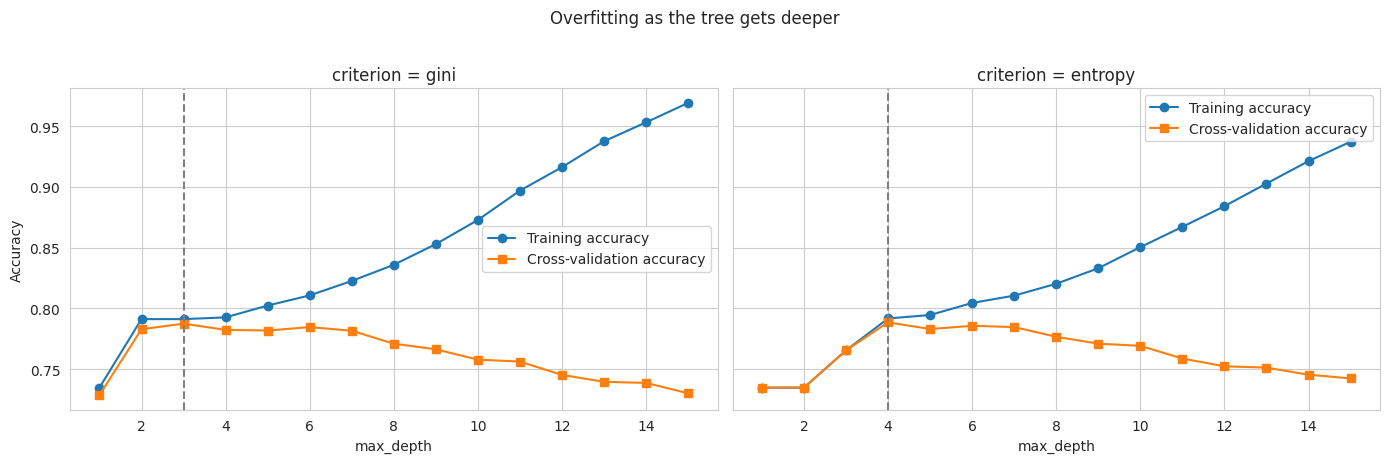

In [8]:
depths = range(1, 16)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, crit in zip(axes, ["gini", "entropy"]):
    tr, cv = [], []
    for d in depths:
        m = DecisionTreeClassifier(criterion=crit, max_depth=d, random_state=42)
        tr.append(m.fit(X_train, y_train).score(X_train, y_train))
        cv.append(cross_val_score(m, X_train, y_train, cv=5).mean())
    ax.plot(depths, tr, "o-", label="Training accuracy")
    ax.plot(depths, cv, "s-", label="Cross-validation accuracy")
    ax.axvline(int(np.argmax(cv)) + 1, ls="--", color="grey")
    ax.set_title(f"criterion = {crit}")
    ax.set_xlabel("max_depth")
    ax.legend()
axes[0].set_ylabel("Accuracy")
plt.suptitle("Overfitting as the tree gets deeper", y=1.02)
plt.tight_layout()
plt.show()

**Observation:** Training accuracy keeps rising with depth, while cross-validation accuracy peaks at a shallow depth and then falls. The gap between the two curves is overfitting. Both criteria behave similarly.

### 5(c) Choosing the best parameters with Grid Search
Because churners are the minority class, the search optimizes the **F1-score** (with 5-fold cross-validation on the training set) instead of plain accuracy. Depth is restricted to 3–8 to keep the tree interpretable.

In [9]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_samples_leaf": [10, 20, 50],
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,
                    scoring="f1", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters :", grid.best_params_)
print("Best CV F1-score: {:.3f}".format(grid.best_score_))

model = grid.best_estimator_          # final Decision Tree model
print("\nFinal tree -> depth:", model.get_depth(), "| leaves:", model.get_n_leaves())

Best parameters : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10}
Best CV F1-score: 0.588

Final tree -> depth: 3 | leaves: 8


## Step 6 — Predicting churn for the test data

In [10]:
y_pred = model.predict(X_test)                    # predicted class (0 / 1)
y_prob = model.predict_proba(X_test)[:, 1]        # probability of churn

results = X_test.copy()
pd.DataFrame({"Actual": y_test.values[:10], "Predicted": y_pred[:10],
              "P(churn)": y_prob[:10].round(3)})

,Actual,Predicted,P(churn)
0,0,0,0.000
1,0,1,0.551
2,0,0,0.047
3,0,1,0.551
4,0,0,0.000
5,0,1,0.551
6,0,1,0.551
7,0,0,0.277
8,0,0,0.017
9,1,0,0.277


## Step 7 — Model evaluation: Confusion Matrix, Accuracy, Precision, Recall, F1-Score

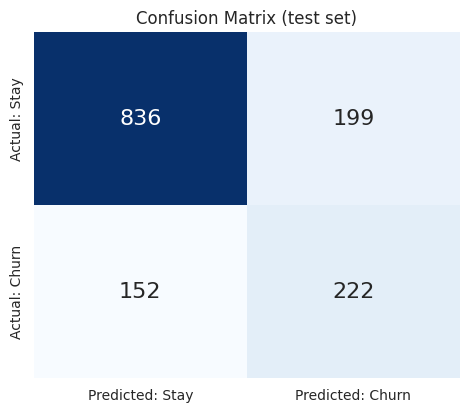

TN = 836  (stayed, predicted stay)      FP = 199  (stayed, predicted churn)
FN = 152  (churned, predicted stay)     TP = 222  (churned, predicted churn)


In [11]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 16},
            xticklabels=["Predicted: Stay", "Predicted: Churn"],
            yticklabels=["Actual: Stay", "Actual: Churn"])
plt.title("Confusion Matrix (test set)")
plt.show()

print(f"TN = {tn}  (stayed, predicted stay)      FP = {fp}  (stayed, predicted churn)")
print(f"FN = {fn}  (churned, predicted stay)     TP = {tp}  (churned, predicted churn)")

In [12]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

metrics = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
                        "Score": [acc, prec, rec, f1, auc]}).round(3)
display(metrics.set_index("Metric"))

print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

,Score
Metric,
Accuracy,0.751
Precision,0.527
Recall,0.594
F1-Score,0.558
ROC-AUC,0.787


Classification report:

              precision    recall  f1-score   support

      Stayed       0.85      0.81      0.83      1035
     Churned       0.53      0.59      0.56       374

    accuracy                           0.75      1409
   macro avg       0.69      0.70      0.69      1409
weighted avg       0.76      0.75      0.76      1409



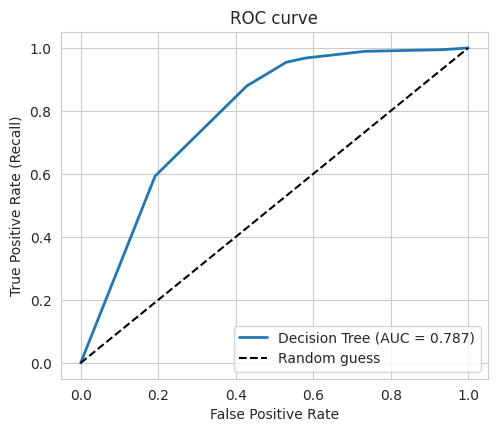

In [13]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, lw=2, label=f"Decision Tree (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC curve"); plt.legend()
plt.show()

**Interpretation**
* **Accuracy** — overall proportion of correct predictions.
* **Precision** (churn) — of the customers predicted to churn, the fraction who really churned. Low precision means retention offers are wasted on some loyal customers.
* **Recall** (churn) — of the customers who really churned, the fraction the model caught. Low recall means churners are being missed.
* **F1-score** — harmonic mean of precision and recall, the best single number for an imbalanced problem.
* The model catches roughly 6 out of 10 churners with about 5 out of 10 alerts being correct, which is clearly better than guessing (the base churn rate is only 26.5%). A single, small tree is easy to explain but is not the most powerful model; see Step 9 for how recall can be improved.

## Step 8 — Visualizing the Decision Tree and the most influential features

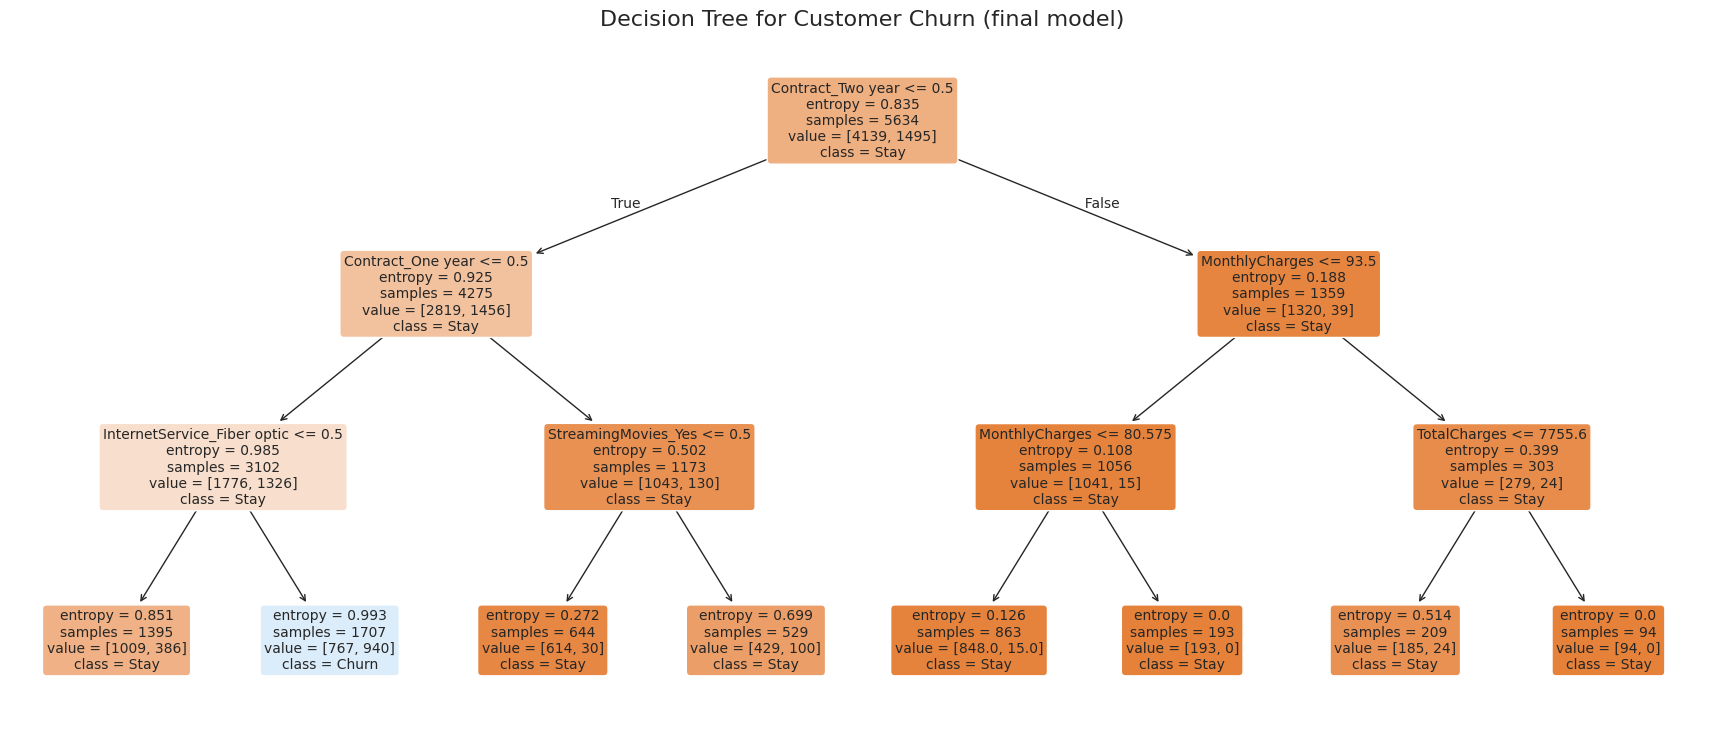

In [14]:
plt.figure(figsize=(22, 9))
plot_tree(model, feature_names=X.columns, class_names=["Stay", "Churn"],
          filled=True, rounded=True, fontsize=10, proportion=False, impurity=True)
plt.title("Decision Tree for Customer Churn (final model)", fontsize=16)
plt.show()

In [15]:
# The same tree as readable IF-THEN rules
print(export_text(model, feature_names=list(X.columns), show_weights=True))

|--- Contract_Two year <= 0.50
|   |--- Contract_One year <= 0.50
|   |   |--- InternetService_Fiber optic <= 0.50
|   |   |   |--- weights: [1009.00, 386.00] class: 0
|   |   |--- InternetService_Fiber optic >  0.50
|   |   |   |--- weights: [767.00, 940.00] class: 1
|   |--- Contract_One year >  0.50
|   |   |--- StreamingMovies_Yes <= 0.50
|   |   |   |--- weights: [614.00, 30.00] class: 0
|   |   |--- StreamingMovies_Yes >  0.50
|   |   |   |--- weights: [429.00, 100.00] class: 0
|--- Contract_Two year >  0.50
|   |--- MonthlyCharges <= 93.50
|   |   |--- MonthlyCharges <= 80.58
|   |   |   |--- weights: [848.00, 15.00] class: 0
|   |   |--- MonthlyCharges >  80.58
|   |   |   |--- weights: [193.00, 0.00] class: 0
|   |--- MonthlyCharges >  93.50
|   |   |--- TotalCharges <= 7755.60
|   |   |   |--- weights: [185.00, 24.00] class: 0
|   |   |--- TotalCharges >  7755.60
|   |   |   |--- weights: [94.00, 0.00] class: 0



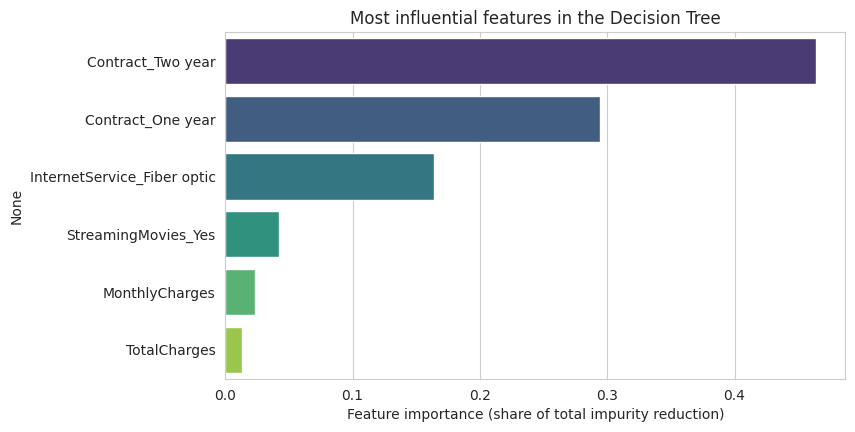

,Importance
Contract_Two year,0.464
Contract_One year,0.294
InternetService_Fiber optic,0.164
StreamingMovies_Yes,0.042
MonthlyCharges,0.024
TotalCharges,0.013


In [16]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
imp = imp[imp > 0]

plt.figure(figsize=(8, 4.5))
sns.barplot(x=imp.values, y=imp.index, palette="viridis")
plt.xlabel("Feature importance (share of total impurity reduction)")
plt.title("Most influential features in the Decision Tree")
plt.show()
imp.round(3).to_frame("Importance")

**How to read the tree:** each box shows the splitting question, the impurity (`entropy`), the number of training samples, the class counts `[stay, churn]` and the majority class (colour: orange = stay, blue = churn). Starting at the root and following the answers down to a leaf gives the prediction for a customer (the **left** branch is taken when the condition is *True*, the right branch when it is *False*).

The **first split is on the contract type** (two-year contracts are almost always retained), followed by **one-year contracts** and then **Fiber-optic internet**. The rule that predicts churn is: *month-to-month contract **and** Fiber-optic internet service*.

## Step 9 — Analysis of results and the key factors behind churn
### 9(a) Churn rate for the important factors
The tree tells us *which* features matter; grouping the data shows *how strongly* each factor is linked to churn.

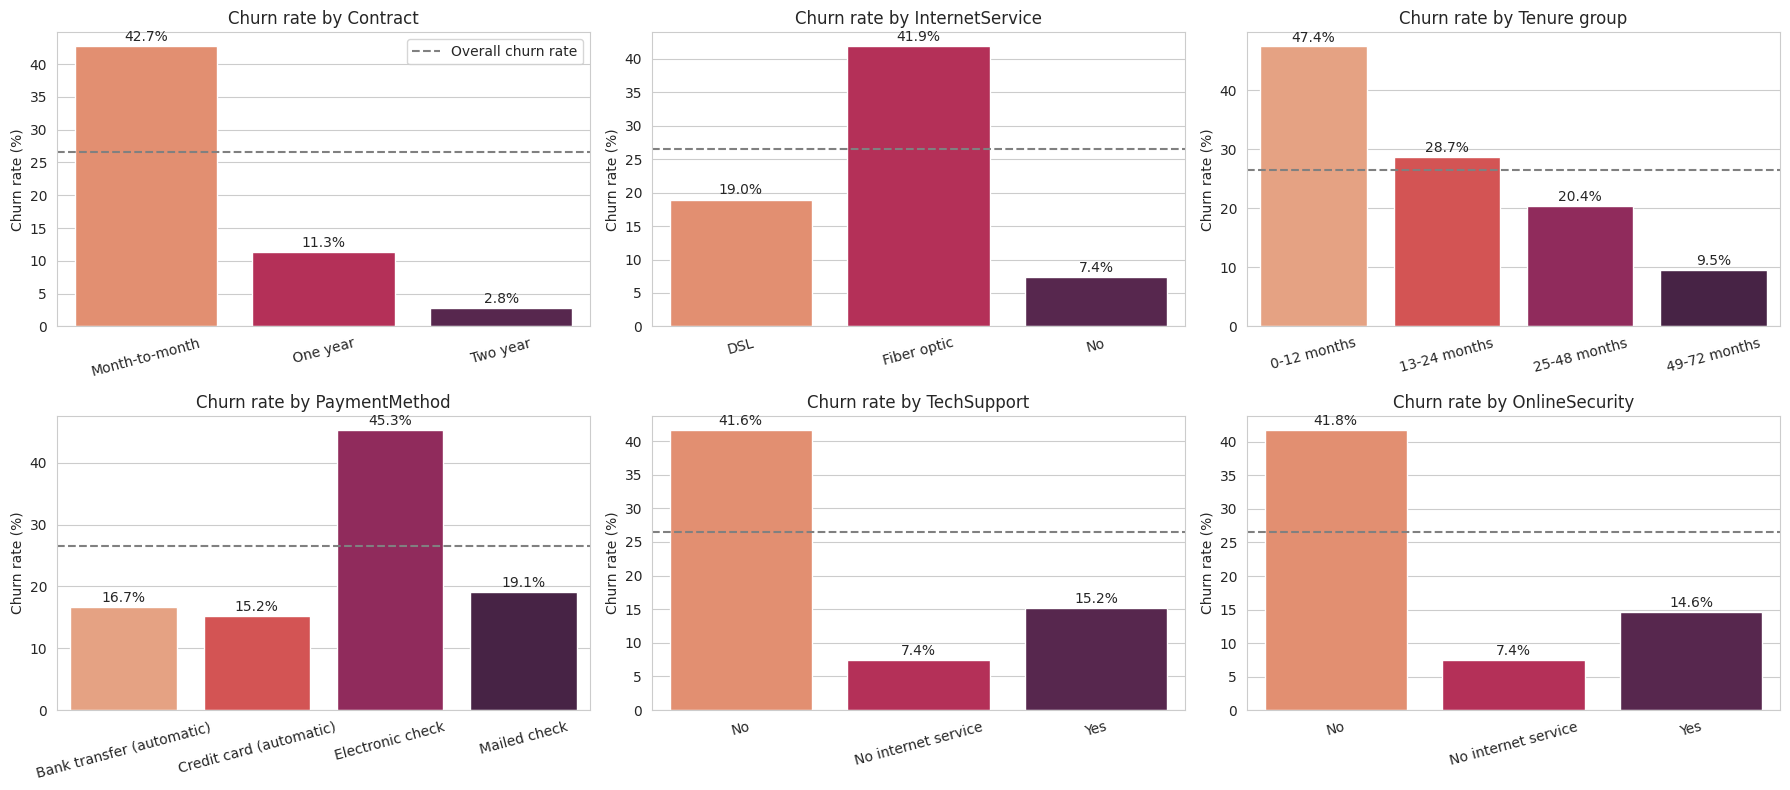

In [17]:
raw = pd.read_csv(FILE if os.path.exists(FILE) else URL)
raw["Churn_flag"] = (raw["Churn"] == "Yes").astype(int)
raw["Tenure group"] = pd.cut(raw["tenure"], [-1, 12, 24, 48, 72],
                             labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"])

factors = ["Contract", "InternetService", "Tenure group", "PaymentMethod", "TechSupport", "OnlineSecurity"]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.ravel(), factors):
    rate = raw.groupby(col)["Churn_flag"].mean().mul(100)
    sns.barplot(x=rate.index.astype(str), y=rate.values, palette="rocket_r", ax=ax)
    ax.axhline(raw["Churn_flag"].mean() * 100, ls="--", color="grey", label="Overall churn rate")
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)"); ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=15)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

**Key factors contributing to churn**

| Factor | Finding |
|---|---|
| **Contract type** | Month-to-month customers churn by far the most (~43%); one-year ≈ 11%, two-year ≈ 3% |
| **Internet service** | Fiber-optic users churn ≈ 42% vs DSL ≈ 19% and no internet ≈ 7% |
| **Tenure** | New customers are the most at risk: ≈ 47% churn in the first 12 months vs ≈ 10% after 4 years |
| **Payment method** | Electronic-check users churn ≈ 45%, versus ≈ 15–19% for other methods, especially automatic payment |
| **Support services** | Customers **without** Tech Support or Online Security churn ≈ 42%, versus ≈ 15% for customers who have them |
| **Gender** | No meaningful difference (≈ 27% vs 26%) |

*Note: these are associations found in the data, not proof of cause and effect.*

### 9(b) Improving recall with class weights
A business would usually rather contact a few extra customers than lose real churners. Setting `class_weight="balanced"` makes the tree treat mistakes on the minority (churn) class as more costly. We re-tune with the same grid and compare.

Best parameters (balanced): {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 50}


,Tuned tree,Tuned tree + class_weight='balanced'
Accuracy,0.751,0.738
Precision,0.527,0.504
Recall,0.594,0.807
F1-Score,0.558,0.621
ROC-AUC,0.787,0.836


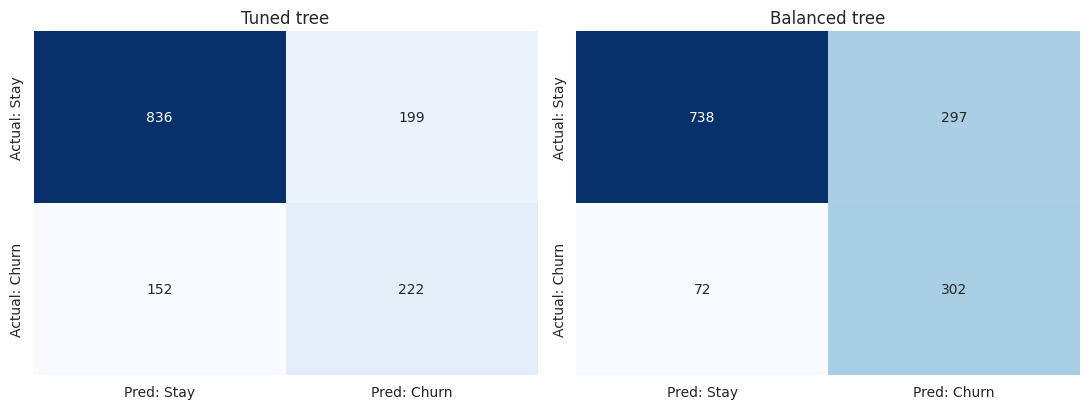

In [18]:
grid_bal = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight="balanced"),
                        param_grid, scoring="f1", cv=5, n_jobs=-1).fit(X_train, y_train)
model_bal = grid_bal.best_estimator_
print("Best parameters (balanced):", grid_bal.best_params_)

def scores(m):
    p = m.predict(X_test)
    return [accuracy_score(y_test, p), precision_score(y_test, p), recall_score(y_test, p),
            f1_score(y_test, p), roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])]

comp = pd.DataFrame({"Tuned tree": scores(model), "Tuned tree + class_weight='balanced'": scores(model_bal)},
                    index=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]).round(3)
display(comp)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, m, t in zip(axes, [model, model_bal], ["Tuned tree", "Balanced tree"]):
    sns.heatmap(confusion_matrix(y_test, m.predict(X_test)), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred: Stay", "Pred: Churn"], yticklabels=["Actual: Stay", "Actual: Churn"], ax=ax)
    ax.set_title(t)
plt.tight_layout()
plt.show()

**Observation:** The balanced tree gives up a little accuracy and precision but **catches far more churners (recall ≈ 0.81 vs ≈ 0.59)** and has a better F1-score and ROC-AUC. For a retention campaign, where missing a churner costs more than contacting a loyal customer, this version is the more useful one.

## Step 10 — Summary of findings and business recommendations
### Summary
* The Telco Customer Churn dataset (7,043 customers) was cleaned (11 blank `TotalCharges` values fixed), one-hot encoded and split 80:20.
* An unrestricted Decision Tree **overfits** (≈ 100 % training accuracy but far lower test accuracy). Limiting depth and leaf size with cross-validated Grid Search fixed this.
* The tuned tree reaches about **75 % accuracy** with precision ≈ 0.53, recall ≈ 0.59 and F1 ≈ 0.56. Using `class_weight="balanced"` raises recall to about **0.81**.
* The most influential factors are the **contract type**, **Fiber-optic internet service** and **tenure**, with electronic-check payment and lack of support services as further risk signals.

### Recommended retention strategies
1. **Convert month-to-month customers to longer contracts** — offer discounts, free upgrades or bonus data for 1- or 2-year plans.
2. **Target the high-risk group (month-to-month + Fiber optic)** with proactive outreach, service-quality checks and price/loyalty offers.
3. **Strengthen the first 12 months** — welcome calls, onboarding help and early check-ins, since new customers churn the most.
4. **Bundle Tech Support and Online Security** free for a trial period; customers with these services rarely leave.
5. **Move customers from electronic cheque to automatic payment** (bank transfer / credit card) with a small incentive.
6. **Use the model's churn probability** to rank customers and spend the retention budget on those with the highest risk and value.

**Conclusion:** A Decision Tree classifier was built and evaluated for churn prediction. It is easy to interpret, identifies the main drivers of churn and provides actionable rules that support data-driven customer-retention decisions.

---
# Answers to Questions

### Q1. What is classification, and how does it differ from regression?
**Classification** is a supervised learning task in which the model learns from labelled data to predict a **discrete category (class label)** for new data — e.g. churn / no churn, spam / not spam, disease / no disease.

**Regression** is a supervised learning task that predicts a **continuous numerical value** — e.g. house price, temperature, monthly sales.

| Basis | Classification | Regression |
|---|---|---|
| Output | Discrete class label | Continuous numeric value |
| Example | Will the customer churn? (Yes/No) | How much will the customer spend next month? |
| Algorithms | Decision Tree, Logistic Regression, KNN, SVM, Naive Bayes | Linear Regression, Ridge/Lasso, Decision Tree Regressor, SVR |
| Evaluation metrics | Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix | MAE, MSE, RMSE, R² |
| Decision boundary | Separates classes | Fits a line/curve through the data |

### Q2. Explain the working principle of the Decision Tree algorithm.
A Decision Tree is a flowchart-like model that makes predictions by asking a sequence of simple questions about the features. It consists of:
* **Root node** – the top node holding the whole dataset,
* **Internal (decision) nodes** – each tests one feature (e.g. *Contract = Two year?*),
* **Branches** – the outcomes of the test,
* **Leaf nodes** – the final class prediction.

**Building the tree (top-down, greedy, recursive partitioning)**
1. Start with all training data at the root.
2. For every feature (and possible threshold) calculate how well it splits the data using an **impurity measure** (Gini Index or Entropy / Information Gain).
3. Choose the split that gives the **largest impurity reduction** (purest child nodes).
4. Divide the data into child nodes and repeat steps 2–3 **recursively** on each child.
5. Stop when a **stopping condition** is met — all samples in a node belong to one class, `max_depth` is reached, or the node has too few samples (`min_samples_split` / `min_samples_leaf`). The node then becomes a leaf labelled with the majority class.

**Predicting:** a new customer is passed from the root down the tree, following the branch that matches its feature values, until it reaches a leaf; the leaf's class is the prediction. Every path from root to leaf is an easy-to-read **IF–THEN rule**.

### Q3. Differentiate between Gini Index and Entropy as splitting criteria.
Both measure the **impurity** of a node. A pure node (all samples in one class) has impurity 0. For class proportions $p_i$:

$$\text{Gini} = 1 - \sum_{i=1}^{c} p_i^{2} \qquad\qquad \text{Entropy} = -\sum_{i=1}^{c} p_i \log_2 p_i$$

Entropy is used to compute **Information Gain** = Entropy(parent) − weighted average Entropy(children).

| Basis | Gini Index | Entropy (Information Gain) |
|---|---|---|
| Formula | $1-\sum p_i^2$ | $-\sum p_i\log_2 p_i$ |
| Range (2 classes) | 0 to 0.5 | 0 to 1 |
| Computation | Faster (no logarithm) | Slightly slower (logarithm) |
| Behaviour | Tends to isolate the largest class into its own pure node | Tends to produce slightly more balanced trees |
| Used by | CART algorithm (scikit-learn default) | ID3 and C4.5 algorithms |
| Results in practice | Very similar trees and accuracy in most cases | Very similar trees and accuracy in most cases |

### Q4. What is a Confusion Matrix? Explain its components.
A **Confusion Matrix** is a table that compares the model's predicted classes with the actual classes on the test data. For binary classification (Positive = customer churns) it is a 2 × 2 table:

| | **Predicted: Churn** | **Predicted: Stay** |
|---|---|---|
| **Actual: Churn** | **TP** – True Positive | **FN** – False Negative |
| **Actual: Stay** | **FP** – False Positive | **TN** – True Negative |

* **True Positive (TP):** the customer churned and the model predicted churn — correct.
* **True Negative (TN):** the customer stayed and the model predicted stay — correct.
* **False Positive (FP)** (Type I error): the customer stayed but the model predicted churn — a retention offer is wasted.
* **False Negative (FN)** (Type II error): the customer churned but the model predicted stay — a lost customer that was not caught (usually the costliest error).

All metrics (accuracy, precision, recall, F1) are calculated from these four numbers. In this experiment the matrix is shown in Step 7.

### Q5. Define Accuracy, Precision, Recall, and F1-Score. Why are these metrics important?
| Metric | Formula | Meaning (churn example) |
|---|---|---|
| **Accuracy** | $\dfrac{TP+TN}{TP+TN+FP+FN}$ | Fraction of all customers classified correctly |
| **Precision** | $\dfrac{TP}{TP+FP}$ | Of the customers predicted to churn, how many really churned (quality of alerts) |
| **Recall** (Sensitivity / TPR) | $\dfrac{TP}{TP+FN}$ | Of the customers who really churned, how many the model caught (coverage) |
| **F1-Score** | $2\times\dfrac{Precision\times Recall}{Precision+Recall}$ | Harmonic mean of precision and recall; balances both |

**Why they are important**
* Accuracy alone is **misleading on imbalanced data**. Only ~26.5 % of the customers churn, so a useless model that predicts "stay" for everyone would still be 73.5 % accurate but would catch **zero** churners.
* **Precision** matters when false alarms are costly (e.g. expensive retention offers); **Recall** matters when missing a positive is costly (e.g. losing a customer, missing a disease).
* **F1-score** gives one balanced number when there is a trade-off between precision and recall.
* Together they show *what kind* of errors the model makes and help choose the model and settings that best fit the business goal.

### Q6. What is overfitting in a Decision Tree? How can it be reduced?
**Overfitting** occurs when the tree grows too deep and complex and learns the **noise and quirks of the training data** instead of the general pattern. It shows up as very high training accuracy but much lower test accuracy (in this experiment the unrestricted tree scored ≈ 99.8 % on training data but only ≈ 73 % on test data). Deep trees have many small leaves containing only a few samples, which do not generalize.

**Ways to reduce overfitting**
1. **Pre-pruning (early stopping):** limit `max_depth`, set `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes` or a minimum impurity decrease.
2. **Post-pruning:** grow the full tree and then cut back weak branches, e.g. **cost-complexity pruning** (`ccp_alpha` in scikit-learn).
3. **Cross-validation** and grid search to choose the best hyper-parameters (as done in Step 5).
4. **Ensemble methods:** Random Forest (bagging) or Gradient Boosting combine many trees to reduce variance.
5. **More training data** and **feature selection** (removing irrelevant or noisy features).

### Q7. Why is customer churn prediction important for businesses?
* **Retention is cheaper than acquisition** — winning a new customer typically costs several times more than keeping an existing one.
* **Protects revenue and profit** — every customer who leaves takes future revenue and lifetime value with them.
* **Enables proactive, targeted action** — customers at high risk can be contacted early with personalised offers, better service or contract upgrades, before they leave.
* **Efficient use of the marketing budget** — retention spending is focused on the customers who are actually at risk and most valuable.
* **Reveals the reasons for churn** — models highlight factors such as contract type, pricing or poor service quality, guiding improvements to products and processes.
* **Improves customer satisfaction and loyalty**, and supports long-term growth and competitive advantage — especially in subscription-based sectors such as telecom, banking, insurance and streaming.

### Q8. What are the advantages and limitations of the Decision Tree algorithm?
**Advantages**
* Very **easy to understand and interpret** — the tree can be visualized and read as IF–THEN rules.
* **No feature scaling or normalization** is needed.
* Handles both **numerical and categorical** data, and non-linear relationships.
* Performs implicit **feature selection** (the most useful features appear near the root).
* Requires **little data preparation** and is fast to train and predict.

**Limitations**
* **Prone to overfitting**, especially deep trees, so pruning or depth limits are needed.
* **Unstable / high variance** — a small change in the data can produce a completely different tree.
* **Greedy algorithm** — each split is chosen locally, so the globally optimal tree is not guaranteed.
* **Biased on imbalanced data** and towards features with many levels.
* Axis-parallel splits make it poor at capturing some relationships (e.g. diagonal boundaries), and it is usually **less accurate than ensemble methods** (Random Forest, XGBoost).
* Cannot **extrapolate** beyond the range of the training data (for regression trees).

### Q9. Mention three real-world applications of Decision Tree Classification other than customer churn prediction.
1. **Medical diagnosis** – classifying whether a patient has a disease (e.g. diabetes, heart disease, cancer) from symptoms and test results.
2. **Loan / credit-risk approval** – deciding whether to approve a loan or credit card by classifying applicants as low- or high-risk from income, credit history and employment.
3. **Fraud detection** – classifying credit-card or insurance transactions as genuine or fraudulent.

*(Other examples: email spam filtering, predicting employee attrition, crop/disease classification in agriculture, product recommendation and quality-control defect detection.)*

### Q10. How can the insights obtained from a churn prediction model help organizations improve customer retention and business profitability?
* **Identify at-risk customers early:** the model's churn probability lets the company rank customers and contact the most likely leavers *before* they cancel.
* **Personalized retention offers:** discounts, contract upgrades, loyalty rewards or add-on services can be matched to each risk group instead of using one costly campaign for everyone.
* **Address the root causes:** the rules and feature importances show what drives churn (here: month-to-month contracts, Fiber-optic service problems, a customer's first year, electronic-cheque payment, missing tech-support) so the business can fix pricing, service quality or onboarding.
* **Prioritize by value:** combining churn risk with customer lifetime value directs the retention budget to the customers who matter most.
* **Increase profitability:** higher retention means steady recurring revenue, lower acquisition costs, more up-selling / cross-selling opportunities and higher customer lifetime value.
* **Continuous improvement:** tracking the model's predictions against actual outcomes and the success of retention campaigns creates a feedback loop for better decisions over time.